# 🌍 World Happiness Report - Exploratory Data Analysis

> *What makes a nation truly happy? Is it wealth, freedom, health, or something deeper?*

This notebook explores the **World Happiness Report dataset (2005–2022)**, an annual survey by the **Gallup World Poll** that measures life satisfaction across 150+ countries.

We analyze how factors like **GDP, social support, life expectancy, freedom, generosity, and corruption** relate to happiness scores, and how these trends have evolved over time.

---

**Dataset:** [World Happiness Report – Kaggle](https://www.kaggle.com/datasets/usamabuttar/world-happiness-report-2005-present)  
**Author:** Shashank Mekkiramane Lingaraju
**Tool:** Python (Pandas, Seaborn, Matplotlib, Plotly)


## ⚙️ Phase 1 - Setup & Installation

Before we begin, we install and import all the necessary libraries for data manipulation, visualization, and mapping.

In [ ]:
!pip install plotly --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📥 Phase 2 - Downloading the Dataset

We use the **Kaggle API** to directly download the World Happiness Report dataset into our environment.  
The dataset contains happiness scores and contributing factors for 150+ countries from **2005 to 2022**.

In [ ]:
import os

# Paste your username and API token here
os.environ['KAGGLE_USERNAME'] = 'shashankmekkiramane'
os.environ['KAGGLE_KEY'] = 'KGAT_c0567a90f62dd68ed04b7e8b4669894a'

print("✅ Kaggle credentials set!")



✅ Kaggle credentials set!


In [ ]:
!pip install kaggle --quiet

!kaggle datasets download -d usamabuttar/world-happiness-report-2005-present --unzip

print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/usamabuttar/world-happiness-report-2005-present
License(s): CC0-1.0
100% 123k/123k [00:00<00:00, 66.2MB/s]

✅ Dataset downloaded!


In [ ]:
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

print("📁 CSV Files Available:")
for f in csv_files:
    print(f"   → {f}")

📁 CSV Files Available:
   → World Happiness Report.csv


## 🔍 Phase 3 - Loading & Understanding the Data

Let's load the dataset and get a first look at its structure - number of rows, columns, data types, and basic statistics.

**Key columns in the dataset:**
| Column | Description |
|---|---|
| `Country Name` | Name of the country |
| `Regional Indicator` | Geographic region |
| `Year` | Year of survey |
| `Life Ladder` | Happiness Score (0–10 scale) |
| `Log GDP Per Capita` | Economic output per person |
| `Social Support` | Availability of social support |
| `Healthy Life Expectancy` | Average healthy lifespan |
| `Freedom To Make Life Choices` | Personal freedom index |
| `Generosity` | Charitable giving |
| `Perceptions Of Corruption` | Corruption level |
| `Positive/Negative Affect` | Daily emotional experience |
| `Confidence In National Government` | Trust in government |

In [ ]:
# Load the Dataset
df = pd.read_csv('World Happiness Report.csv')

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📊 Shape: 2199 rows × 13 columns


In [ ]:
df.head(10)

,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
0,Afghanistan,South Asia,2008,3.724,7.350,0.451,50.500,0.718,0.168,0.882,0.414,0.258,0.612
1,Afghanistan,South Asia,2009,4.402,7.509,0.552,50.800,0.679,0.191,0.850,0.481,0.237,0.612
2,Afghanistan,South Asia,2010,4.758,7.614,0.539,51.100,0.600,0.121,0.707,0.517,0.275,0.299
3,Afghanistan,South Asia,2011,3.832,7.581,0.521,51.400,0.496,0.164,0.731,0.480,0.267,0.307
4,Afghanistan,South Asia,2012,3.783,7.661,0.521,51.700,0.531,0.238,0.776,0.614,0.268,0.435
5,Afghanistan,South Asia,2013,3.572,7.680,0.484,52.000,0.578,0.063,0.823,0.547,0.273,0.483
6,Afghanistan,South Asia,2014,3.131,7.671,0.526,52.300,0.509,0.106,0.871,0.492,0.375,0.409
7,Afghanistan,South Asia,2015,3.983,7.654,0.529,52.600,0.389,0.082,0.881,0.491,0.339,0.261
8,Afghanistan,South Asia,2016,4.220,7.650,0.559,52.925,0.523,0.044,0.793,0.501,0.348,0.325
9,Afghanistan,South Asia,2017,2.662,7.648,0.491,53.250,0.427,-0.119,0.954,0.435,0.371,0.261


In [ ]:
# Basic Info (data types + null values)

print("📌 Dataset Info:")
df.info()

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country Name                       2199 non-null   object 
 1   Regional Indicator                 2087 non-null   object 
 2   Year                               2199 non-null   int64  
 3   Life Ladder                        2199 non-null   float64
 4   Log GDP Per Capita                 2179 non-null   float64
 5   Social Support                     2186 non-null   float64
 6   Healthy Life Expectancy At Birth   2145 non-null   float64
 7   Freedom To Make Life Choices       2166 non-null   float64
 8   Generosity                         2126 non-null   float64
 9   Perceptions Of Corruption          2083 non-null   float64
 10  Positive Affect                    2175 non-null   float64
 11  Negative Affect                    2183 

In [ ]:
# Summary Statistics

print("📈 Summary Statistics:")
df.describe()

📈 Summary Statistics:


,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
count,2199.000,2199.000,2179.000,2186.000,2145.000,2166.000,2126.000,2083.000,2175.000,2183.000,1838.000
mean,2014.161,5.479,9.390,0.811,63.295,0.748,0.000,0.745,0.652,0.272,0.484
std,4.719,1.126,1.153,0.121,6.901,0.140,0.161,0.186,0.106,0.087,0.193
min,2005.000,1.281,5.527,0.228,6.720,0.258,-0.338,0.035,0.179,0.083,0.069
25%,2010.000,4.647,8.500,0.747,59.120,0.657,-0.112,0.688,0.572,0.208,0.333
50%,2014.000,5.432,9.499,0.836,65.050,0.770,-0.023,0.800,0.663,0.261,0.467
75%,2018.000,6.309,10.373,0.905,68.500,0.859,0.092,0.869,0.738,0.323,0.619
max,2022.000,8.019,11.664,0.987,74.475,0.985,0.703,0.983,0.884,0.705,0.994


In [ ]:
# Check Missing Values

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

print("Missing Values Report:")
print(missing_df[missing_df['Missing Values'] > 0])

Missing Values Report:
                                   Missing Values  Percentage (%)
Confidence In National Government             361          16.417
Perceptions Of Corruption                     116           5.275
Regional Indicator                            112           5.093
Generosity                                     73           3.320
Healthy Life Expectancy At Birth               54           2.456
Freedom To Make Life Choices                   33           1.501
Positive Affect                                24           1.091
Log GDP Per Capita                             20           0.910
Negative Affect                                16           0.728
Social Support                                 13           0.591


## 🧹 Phase 4 - Data Cleaning

Real-world data is never perfect. In this phase we:
- Fix **missing regional indicators** for some countries
- Fill **null values** in numerical columns using median imputation
- **Rename columns** for easier use throughout the analysis
- Fix **country name mismatches** for Plotly's choropleth map
- Perform a final check to ensure the dataset is clean and ready

In [ ]:
# Regional Indicator Fix

# Fill missing Regional Indicator based on Country Name
# (Some countries appear in other years with regions — we forward/back fill)

df['Regional Indicator'] = df.groupby('Country Name')['Regional Indicator']\
                             .transform(lambda x: x.ffill().bfill())

print(f"✅ Regional Indicator missing after fix: {df['Regional Indicator'].isnull().sum()}")

✅ Regional Indicator missing after fix: 112


In [ ]:
# Filling numerical missing values

# Fill numerical columns with median per country
# Median is better than mean — less affected by outliers

numerical_cols = [
    'Log GDP Per Capita', 'Social Support',
    'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices',
    'Generosity', 'Perceptions Of Corruption', 'Positive Affect',
    'Negative Affect', 'Confidence In National Government'
]

for col in numerical_cols:
    df[col] = df.groupby('Country Name')[col]\
                .transform(lambda x: x.fillna(x.median()))

print("✅ Numerical missing values filled with country-wise median!")

✅ Numerical missing values filled with country-wise median!


In [ ]:
# Check if any missing values remain

remaining_missing = df.isnull().sum().sum()
print(f"🔍 Total missing values remaining: {remaining_missing}")

if remaining_missing > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("✅ Dataset is fully clean — No missing values!")

🔍 Total missing values remaining: 325
Regional Indicator                   112
Log GDP Per Capita                     9
Social Support                         1
Healthy Life Expectancy At Birth      32
Generosity                             9
Perceptions Of Corruption             29
Positive Affect                        2
Negative Affect                        1
Confidence In National Government    130
dtype: int64


In [ ]:
# Renaming columns for easier use

df.rename(columns={
    'Country Name'                      : 'country',
    'Regional Indicator'                : 'region',
    'Year'                              : 'year',
    'Life Ladder'                       : 'happiness_score',
    'Log GDP Per Capita'                : 'gdp_per_capita',
    'Social Support'                    : 'social_support',
    'Healthy Life Expectancy At Birth'  : 'life_expectancy',
    'Freedom To Make Life Choices'      : 'freedom',
    'Generosity'                        : 'generosity',
    'Perceptions Of Corruption'         : 'corruption',
    'Positive Affect'                   : 'positive_affect',
    'Negative Affect'                   : 'negative_affect',
    'Confidence In National Government' : 'govt_confidence'
}, inplace=True)

print("✅ Columns renamed successfully!")
print(df.columns.tolist())

✅ Columns renamed successfully!
['country', 'region', 'year', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'generosity', 'corruption', 'positive_affect', 'negative_affect', 'govt_confidence']


In [ ]:
# Plotly Country Name Fix

PLOTLY_NAME_MAP = {
    # Parenthetical Congo names → Plotly short-form
    'Congo (Brazzaville)'        : 'Congo, Rep.',
    'Congo (Kinshasa)'           : 'Congo, Dem. Rep.',

    # New official names that Plotly hasn't adopted yet
    'Czechia'                    : 'Czech Republic',
    'Eswatini'                   : 'Swaziland',
    'Turkiye'                    : 'Turkey',
    'North Macedonia'            : 'Macedonia, FYR',
    'Slovakia'                   : 'Slovak Republic',

    # Special regions / territories
    'Hong Kong S.A.R. of China'  : 'Hong Kong, China',
    'Taiwan Province of China'   : 'Taiwan',
    'State of Palestine'         : 'West Bank and Gaza',
    'Somaliland region'          : 'Somalia',

    # Common short names → Plotly full names
    'Ivory Coast'                : "Cote d'Ivoire",
    'Laos'                       : 'Lao PDR',
    'South Korea'                : 'Korea, Rep.',
    'Russia'                     : 'Russian Federation',
    'Yemen'                      : 'Yemen, Rep.',
}

df['country'] = df['country'].replace(PLOTLY_NAME_MAP)

print('✅ Plotly country names fixed!')
print(f'   Changes applied: {len(PLOTLY_NAME_MAP)}')
print(f'   Unique countries now: {df["country"].nunique()}')


✅ Plotly country names fixed!
   Changes applied: 16
   Unique countries now: 164


In [ ]:
# Filling remaining missing values

numerical_cols = [
    'gdp_per_capita',
    'social_support',
    'life_expectancy',
    'freedom',
    'generosity',
    'corruption',
    'positive_affect',
    'negative_affect',
    'govt_confidence'
]

# Fill any remaining nulls with global median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# For region — fill with 'Unknown' if still missing
df['region'] = df['region'].fillna('Unknown')

print(f"✅ Remaining missing values: {df.isnull().sum().sum()}")

✅ Remaining missing values: 0


In [ ]:
print(f"✅ Final Dataset Shape: {df.shape}")
print(f"📅 Years covered: {df['year'].min()} to {df['year'].max()}")
print(f"🌍 Total countries: {df['country'].nunique()}")
print(f"🗺️  Total regions: {df['region'].nunique()}")
print(f"🔍 Missing values: {df.isnull().sum().sum()}")

✅ Final Dataset Shape: (2199, 13)
📅 Years covered: 2005 to 2022
🌍 Total countries: 164
🗺️  Total regions: 11
🔍 Missing values: 0


## 📊 Phase 5 - Visualization & Analysis

Now the fun begins! We explore the data through **6 powerful visualizations**, each uncovering a different dimension of global happiness.

| # | Chart | Purpose |
|---|---|---|
| 1 | 🌍 World Map | Happiness distribution by country |
| 2 | 🏆 Top & Bottom 10 | Happiest & saddest countries |
| 3 | 🔥 Correlation Heatmap | Which factors drive happiness |
| 4 | 📈 Time Series | Happiness trends over years |
| 5 | 🔵 Scatter Plot | GDP vs Happiness |
| 6 | 📊 Regional Comparison | Which region is happiest |

## Visualizations

### 🌍 Chart 1 - World Happiness Map

A **choropleth map** showing happiness scores by country for the most recent year in the dataset.  
Darker greens indicate **happier countries**, while reds and yellows reflect **lower happiness scores**.

> **Key Insight:** Happiness is not evenly distributed - Western Europe and North America dominate the top, while Sub-Saharan Africa and parts of Asia sit at the bottom.

In [ ]:
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year]

fig = px.choropleth(
    df_latest,
    locations='country',
    locationmode='country names',
    color='happiness_score',
    hover_name='country',
    hover_data={
        'happiness_score': ':.2f',
        'gdp_per_capita': ':.2f',
        'region': True
    },
    color_continuous_scale='RdYlGn',
    title=f'🌍 World Happiness Score by Country',
    labels={'happiness_score': 'Happiness Score'}
)

fig.update_layout(
    title_font_size=20,
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title='Happiness\nScore'),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

### 🏆 Chart 2 - Top & Bottom 10 Countries

Which countries are consistently the **happiest** and **unhappiest** in the world?  
We calculate the **average happiness score** per country across all years to find the true long-term leaders and laggards.

> **Key Insight:** Nordic countries (Finland, Denmark, Iceland) dominate the top 10, while conflict-affected and economically struggling nations occupy the bottom 10.

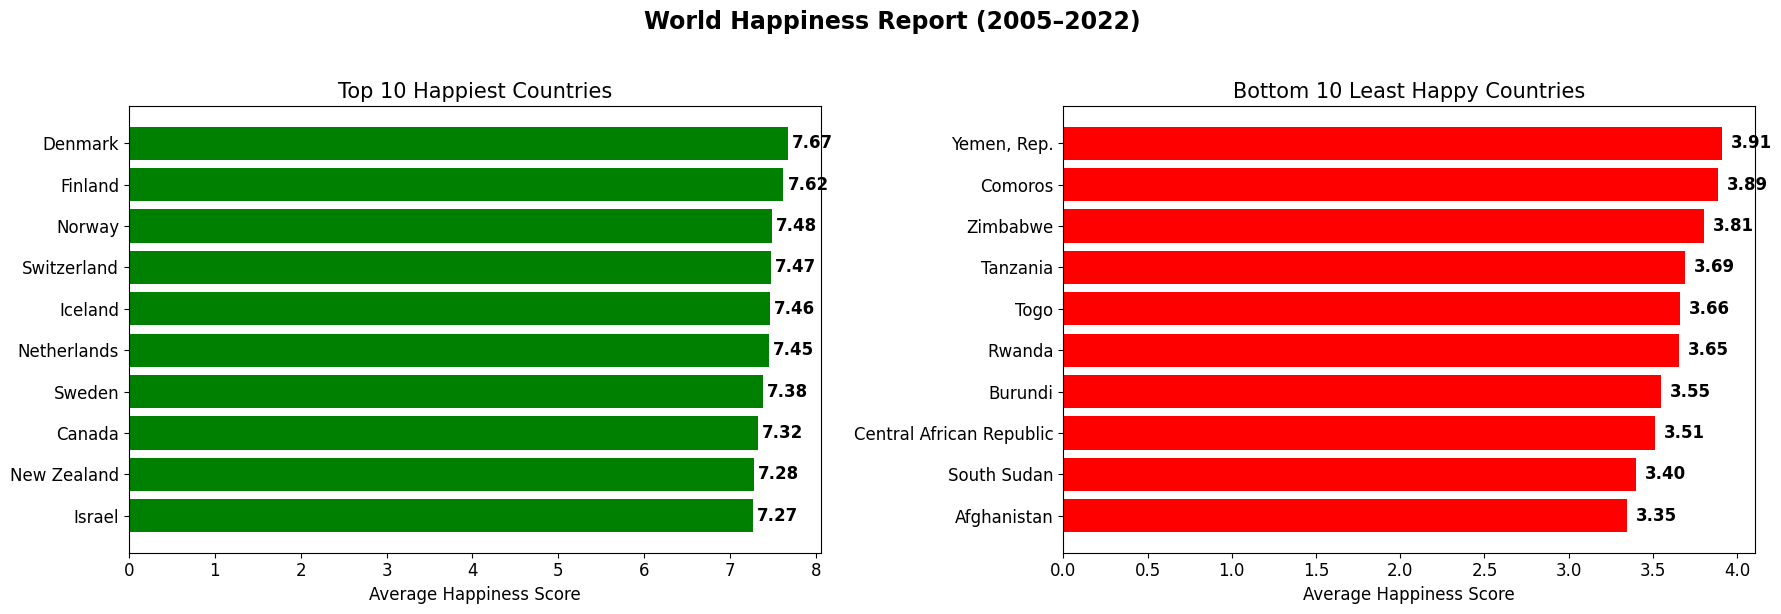

In [ ]:
# Get average happiness score per country across all years
avg_happiness = df.groupby('country')['happiness_score']\
                  .mean().reset_index()\
                  .sort_values('happiness_score', ascending=False)

top10    = avg_happiness.head(10)
bottom10 = avg_happiness.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10
axes[0].barh(top10['country'], top10['happiness_score'],
             color='green')
axes[0].set_title('Top 10 Happiest Countries', fontsize=15)
axes[0].set_xlabel('Average Happiness Score')
axes[0].invert_yaxis()
for i, v in enumerate(top10['happiness_score']):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center',
                 fontweight='bold')

# Bottom 10
axes[1].barh(bottom10['country'], bottom10['happiness_score'],
             color='red')
axes[1].set_title('Bottom 10 Least Happy Countries', fontsize=15)
axes[1].set_xlabel('Average Happiness Score')
axes[1].invert_yaxis()
for i, v in enumerate(bottom10['happiness_score']):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center',
                 fontweight='bold')

plt.suptitle('World Happiness Report (2005–2022)',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔥 Chart 3 - Correlation Heatmap

How strongly does each factor relate to happiness - and to each other?  
A **correlation heatmap** reveals these relationships at a glance.

- 🟢 **Green (positive):** Both variables increase together  
- 🔴 **Red (negative):** One increases as the other decreases  
- Values range from **-1** (perfect negative) to **+1** (perfect positive)

> **Key Insight:** GDP per capita (0.78), social support (0.72), and life expectancy (0.71) are the strongest predictors of happiness. Corruption (-0.45) is the biggest drag.

In [ ]:
corr_cols = [
    'happiness_score', 'gdp_per_capita', 'social_support',
    'life_expectancy', 'freedom', 'generosity',
    'corruption', 'positive_affect', 'negative_affect', 'govt_confidence'
]

corr_matrix = df[corr_cols].corr()
print(corr_matrix)

                 happiness_score  gdp_per_capita  social_support  \
happiness_score            1.000           0.781           0.722   
gdp_per_capita             0.781           1.000           0.679   
social_support             0.722           0.679           1.000   
life_expectancy            0.713           0.814           0.598   
freedom                    0.530           0.363           0.409   
generosity                 0.182           0.004           0.071   
corruption                -0.446          -0.382          -0.228   
positive_affect            0.517           0.241           0.433   
negative_affect           -0.339          -0.245          -0.440   
govt_confidence           -0.089          -0.187          -0.156   

                 life_expectancy  freedom  generosity  corruption  \
happiness_score            0.713    0.530       0.182      -0.446   
gdp_per_capita             0.814    0.363       0.004      -0.382   
social_support             0.598    0.409   

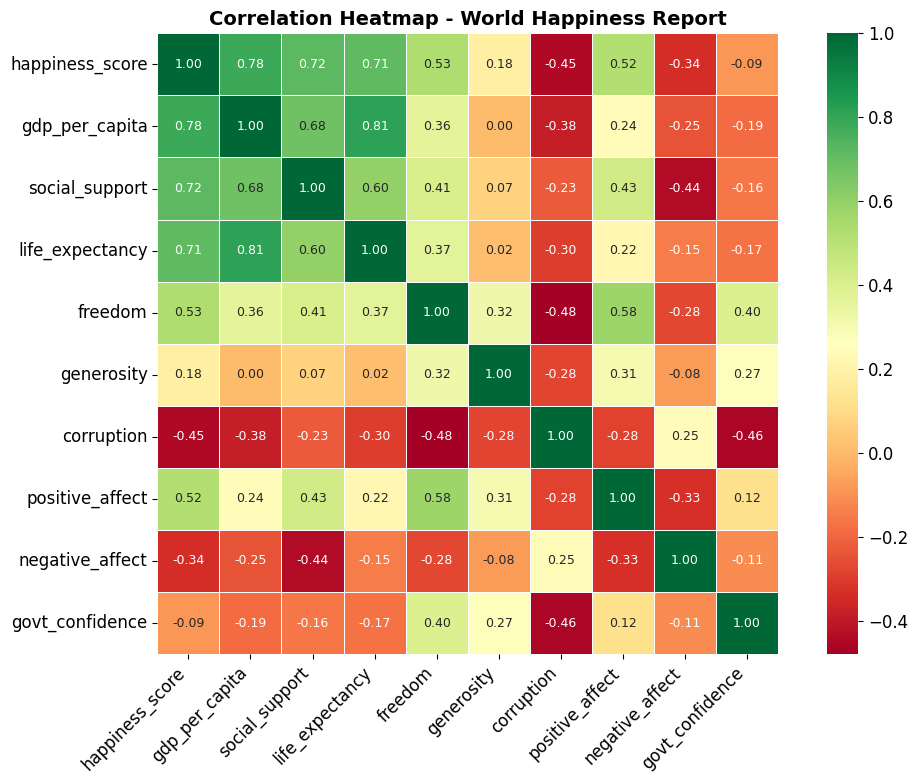

In [ ]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    square=True,
    annot_kws={"size": 9}
)

plt.title("Correlation Heatmap - World Happiness Report", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 📈 Chart 4 - Time Series: Happiness Trends Over Years

How has **global happiness evolved** from 2006 to 2022?  
We also track the **top 5 happiest countries** to see if their lead has grown or narrowed over time.

> **Note:** 2005 data was excluded as only a small number of countries reported that year, causing an artificially high global average.

#### 4.1 - Global Average Happiness Per Year

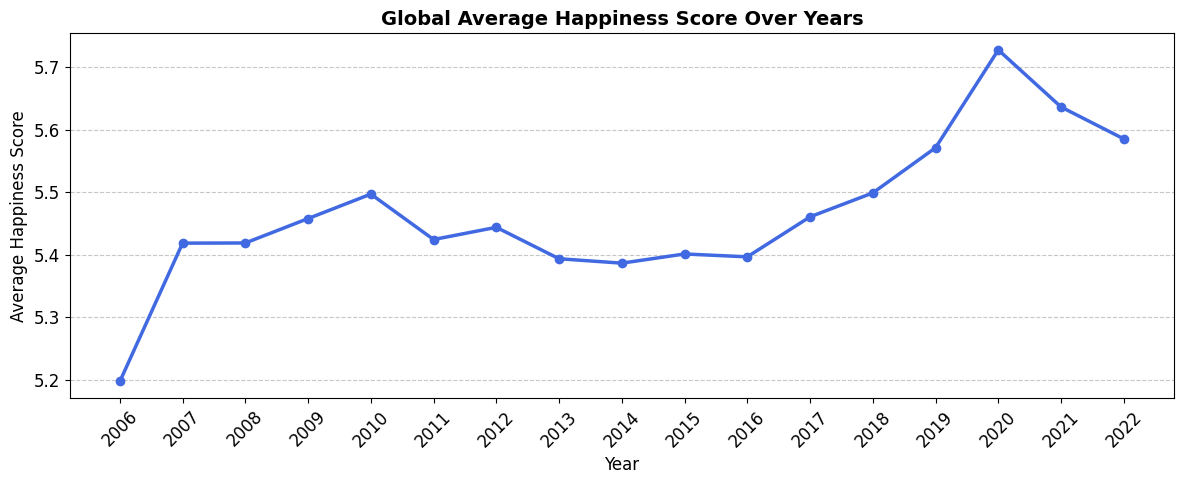

In [ ]:
yearly_avg = df[df['year'] >= 2006].groupby('year')['happiness_score'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly_avg['year'], yearly_avg['happiness_score'],
         marker='o', linewidth=2.5, color='royalblue', markersize=6)

plt.title("Global Average Happiness Score Over Years", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.xticks(yearly_avg['year'].astype(int), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 4.2 - Top 5 Countries Trend Over Years

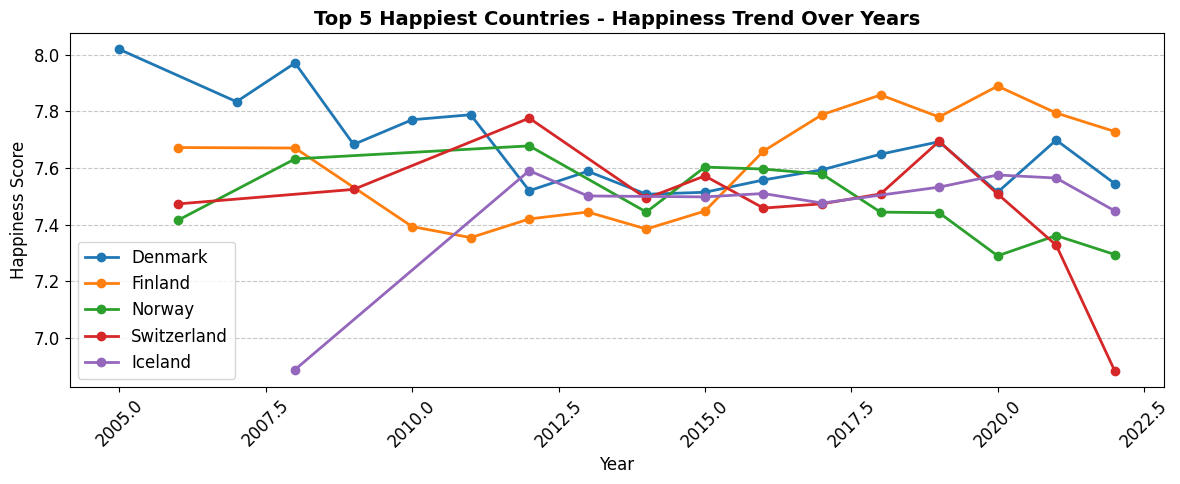

In [ ]:
top5_countries = df.groupby('country')['happiness_score'].mean().nlargest(5).index

df_top5 = df[df['country'].isin(top5_countries)]

plt.figure(figsize=(12, 5))
for country in top5_countries:
    data = df_top5[df_top5['country'] == country]
    plt.plot(data['year'], data['happiness_score'], marker='o', label=country, linewidth=2)

plt.title("Top 5 Happiest Countries - Happiness Trend Over Years", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 🔵 Chart 5 — Scatter Plot: GDP vs Happiness

Does **money really buy happiness?**  
This scatter plot visualizes the relationship between a country's economic output (GDP per capita) and its happiness score.

> **Key Insight:** There is a **clear upward trend** - wealthier countries tend to be happier. However, the relationship is not perfectly linear, showing that GDP alone doesn't explain everything. Some low-GDP countries still score well thanks to strong social bonds and freedom.

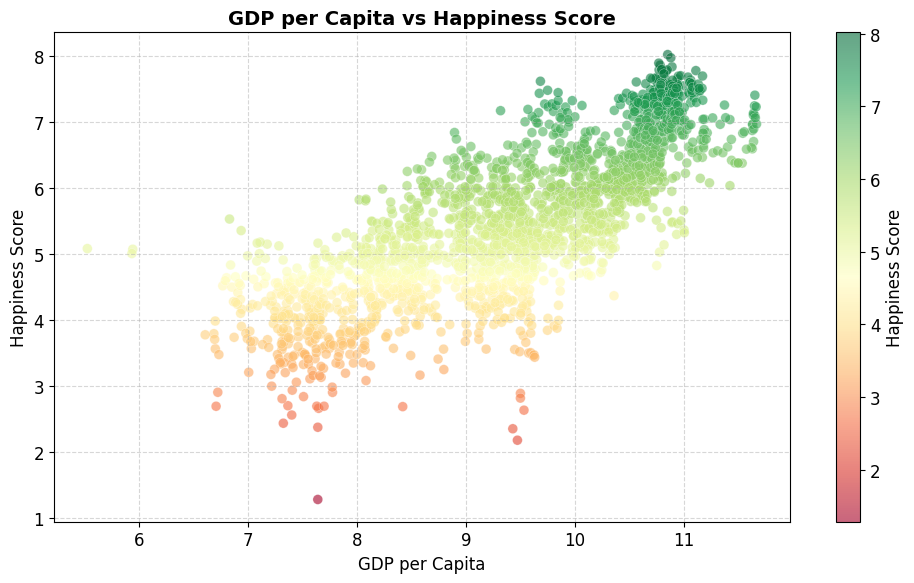

In [ ]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['gdp_per_capita'],
    df['happiness_score'],
    c=df['happiness_score'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='white',
    linewidths=0.3,
    s=50
)

plt.colorbar(scatter, label='Happiness Score')
plt.title("GDP per Capita vs Happiness Score", fontsize=14, fontweight='bold')
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 📊 Chart 6 — Regional Comparison

Which **region of the world** is happiest on average?  
This bar chart compares average happiness scores across all global regions.

> **Key Insight:** Western Europe leads comfortably. Latin America punches above its economic weight thanks to strong social culture. Sub-Saharan Africa and South Asia face the toughest challenges.

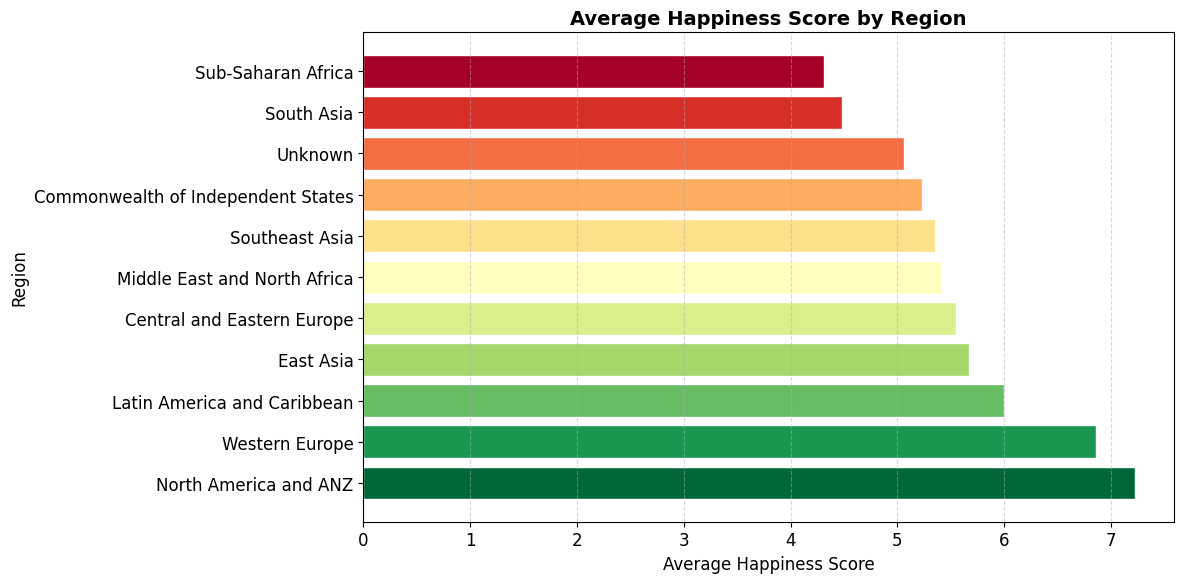

In [ ]:
region_avg = df.groupby('region')['happiness_score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))

bars = plt.barh(
    region_avg['region'],
    region_avg['happiness_score'],
    color=plt.cm.RdYlGn_r([x/10 for x in range(len(region_avg))]),
    edgecolor='white'
)

plt.title("Average Happiness Score by Region", fontsize=14, fontweight='bold')
plt.xlabel("Average Happiness Score")
plt.ylabel("Region")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## 🏁 Final Conclusions

After analyzing happiness data from **150+ countries over 17 years**, here are the most important takeaways:

### 🔑 Key Findings:

1. **💰 Wealth matters, but isn't everything.**  
   GDP per capita has the strongest correlation (0.78) with happiness, but countries like Costa Rica and Mexico consistently outperform their economic peers due to strong social ties.

2. **👫 Social support is the heart of happiness.**  
   Having someone to count on (0.72 correlation) is nearly as important as wealth. Nations with strong community bonds consistently rank higher.

3. **🏥 Health = Happiness.**  
   Life expectancy (0.71) shows that investing in public health directly translates to happier citizens.

4. **🗽 Freedom matters more than we think.**  
   Personal freedom (0.53) contributes meaningfully - people need to feel in control of their lives.

5. **😤 Corruption is happiness's #1 enemy.**  
   The strongest negative factor (-0.45) - corrupt governments erode trust, fairness, and ultimately life satisfaction.

6. **🌍 Geography shapes destiny.**  
   Western Europe dominates the top rankings. Sub-Saharan Africa faces a persistent happiness gap driven by economic and political instability.

7. **📈 Global happiness is slowly improving.**  
   Despite fluctuations, the overall trend from 2006–2022 shows a gradual positive movement in global well-being.

---

### 💡 Final Thought:
> *The happiest nations are not just the richest - they are the ones that invest in people: their health, their freedom, their relationships, and their trust in institutions.*
